# 04 · Funnel Analysis

**Product Analytics Case Study — Phase 3: Exploratory Data Analysis**

Retention tells us whether users come back; the funnel tells us whether
they can complete the product's core job — booking a ride — in the first
place. This notebook traces users through **Signup → Search Started →
Booking Started → Booking Completed**, quantifies conversion and drop-off
at each step, identifies where abandoning users actually give up, and
compares funnel performance by platform and acquisition channel.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import (
    PALETTE, INK, INK_SECONDARY, INK_MUTED, GRID_COLOR, AXIS_COLOR, SURFACE,
    COLOR_GOOD, COLOR_CRITICAL, COLOR_CONTROL, COLOR_TREATMENT,
    BLUE_SEQUENTIAL, DIVERGING,
    set_notebook_style, style_axis, annotate_bars, build_color_map, pct, save_fig,
    load_datasets, compute_funnel, FUNNEL_STAGES,
)

set_notebook_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data" / "raw"
IMAGES_DIR = Path("..") / "images"

users, events, experiments = load_datasets(DATA_DIR)
print(f"users: {users.shape}, events: {events.shape}, experiments: {experiments.shape}")

users: (5000, 9), events: (141813, 11), experiments: (5000, 7)


## Section 1 — Overall Funnel

**Business Question.** Of every 100 users who sign up, how many ever
search, start a booking, and complete one? And critically — **at which
single step do we lose the most users?**

In [2]:
funnel_df = compute_funnel(users, events)
funnel_df.round(1)

,stage,users,pct_of_signups,pct_of_previous_stage,drop_off_pct
0,Signup,5000,100.0,NaN,NaN
1,Search Started,3460,69.2,69.2,30.8
2,Booking Started,1657,33.1,47.9,52.1
3,Booking Completed,1434,28.7,86.5,13.5


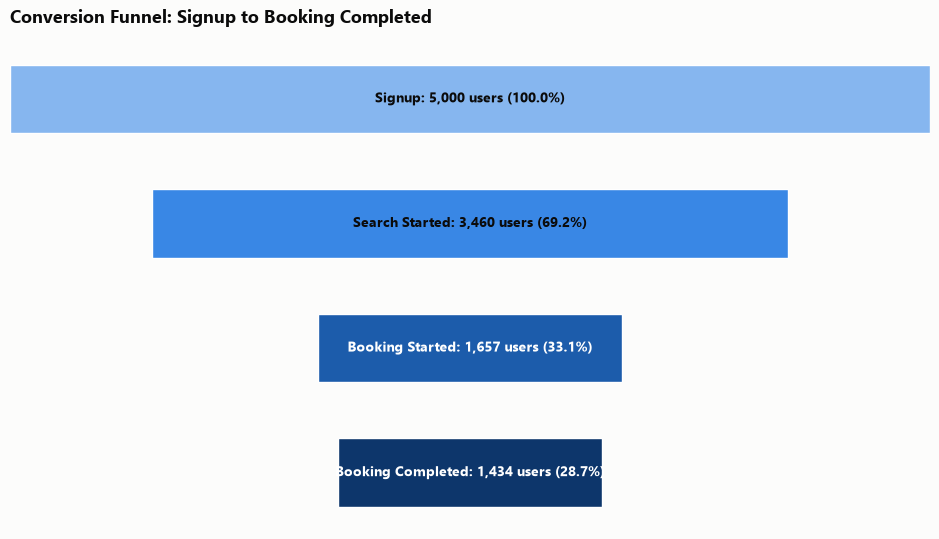

In [3]:
FUNNEL_COLORS = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # ordinal blue ramp: light -> dark = funnel progression
FUNNEL_TEXT_COLORS = [INK, INK, "#ffffff", "#ffffff"]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
max_width = funnel_df["users"].iloc[0]
y_positions = list(range(len(funnel_df)))[::-1]

for i, row in funnel_df.iterrows():
    left = (max_width - row["users"]) / 2
    ax.barh(y_positions[i], row["users"], left=left, height=0.55, color=FUNNEL_COLORS[i])
    label = f"{row['stage']}: {row['users']:,} users ({row['pct_of_signups']:.1f}%)"
    ax.text(max_width / 2, y_positions[i], label, ha="center", va="center",
             fontsize=10, color=FUNNEL_TEXT_COLORS[i], fontweight="bold")

ax.set_xlim(0, max_width)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Conversion Funnel: Signup to Booking Completed", fontsize=13, fontweight="bold", color=INK, pad=14, loc="left")
plt.tight_layout()
save_fig(fig, "23_conversion_funnel", IMAGES_DIR)
plt.show()

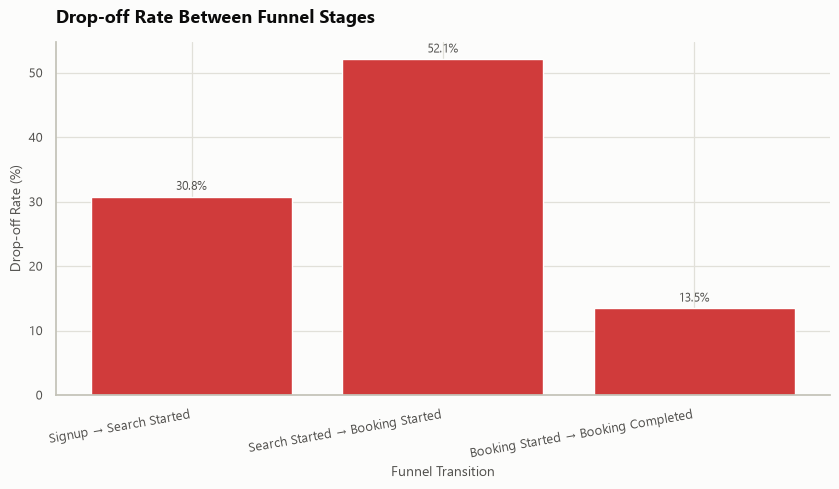

In [4]:
transitions = [f"{funnel_df['stage'][i]} \u2192 {funnel_df['stage'][i + 1]}" for i in range(len(funnel_df) - 1)]
drop_offs = funnel_df["drop_off_pct"].iloc[1:].values

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(transitions, drop_offs, color=COLOR_CRITICAL)
annotate_bars(ax, bars, fmt="{:.1f}%")
style_axis(ax, "Drop-off Rate Between Funnel Stages", "Funnel Transition", "Drop-off Rate (%)")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
save_fig(fig, "24_funnel_dropoff", IMAGES_DIR)
plt.show()

**Business Insight.** The **Search Started → Booking Started** transition
loses roughly half of all searching users — by far the largest single
drop-off in the funnel, dwarfing the **Booking Started → Booking Completed**
step (~13-14% drop-off), which is comparatively healthy. In other words:
**checkout/payment is not the problem — the decision to commit to a
booking in the first place is.**

**Recommendation.** Redirect product investment away from further checkout
polish and toward the search-results-to-booking-intent step: clearer
pricing up front, better ride-option comparison, or a low-friction
"quick rebook" path for repeat routes.

## Section 2 — Abandonment: Where Do Non-Converting Sessions Actually Stop?

**Business Question.** Among sessions that searched but never completed a
booking, what's the *last* thing the user did before giving up? This
pinpoints the exact UI moment to redesign, rather than just the funnel
stage.

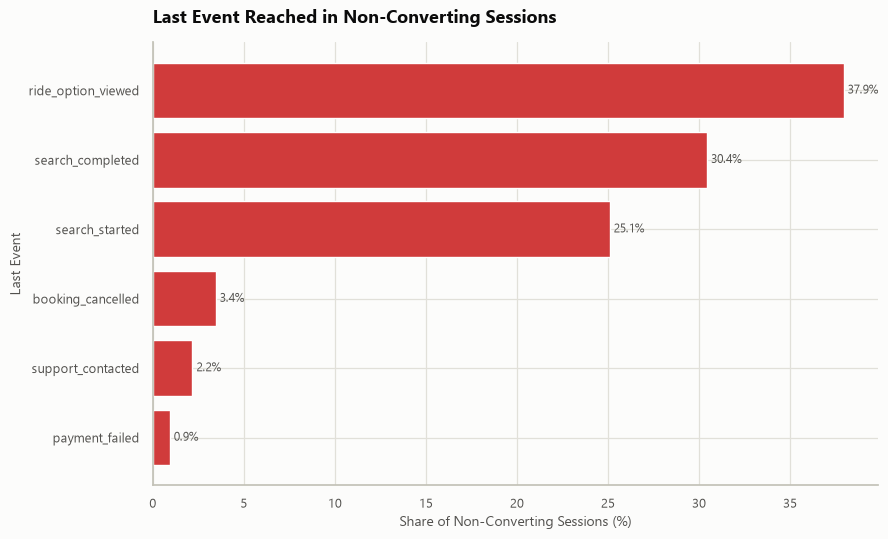

In [5]:
search_sessions = set(events.loc[events["event_name"] == "search_started", "session_id"])
converting_sessions = set(events.loc[events["event_name"] == "booking_completed", "session_id"])
non_converting_sessions = search_sessions - converting_sessions

non_converting_events = events[events["session_id"].isin(non_converting_sessions)].copy()
non_converting_events = non_converting_events.sort_values("event_time")
last_event_per_session = non_converting_events.groupby("session_id").tail(1)

abandonment_points = last_event_per_session["event_name"].value_counts()
abandonment_pct = (abandonment_points / len(non_converting_sessions) * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(abandonment_pct.index, abandonment_pct.values, color=COLOR_CRITICAL)
annotate_bars(ax, bars, fmt="{:.1f}%", horizontal=True)
style_axis(ax, "Last Event Reached in Non-Converting Sessions", "Share of Non-Converting Sessions (%)", "Last Event", grid_axis="x")
plt.tight_layout()
save_fig(fig, "25_abandonment_points", IMAGES_DIR)
plt.show()

**Business Insight.** The largest single abandonment point is right after
**viewing ride options**, followed closely by right after **search
results** — together these account for the majority of abandonment. Very
few sessions abandon *after* starting a booking. **Users are giving up
while comparing options, not while checking out.**

**Recommendation.** Prioritise a UX test on the ride-option comparison
screen specifically: surfacing price/ETA more prominently, reducing choice
overload, or adding urgency/social-proof cues (e.g. "3 people booked this
route today") at exactly the point users currently drop off.

## Section 3 — Funnel by Platform

**Business Question.** Does the funnel leak at the same step on every
platform, or does Web (already flagged as the weakest platform on
retention) also underperform on a specific funnel step?

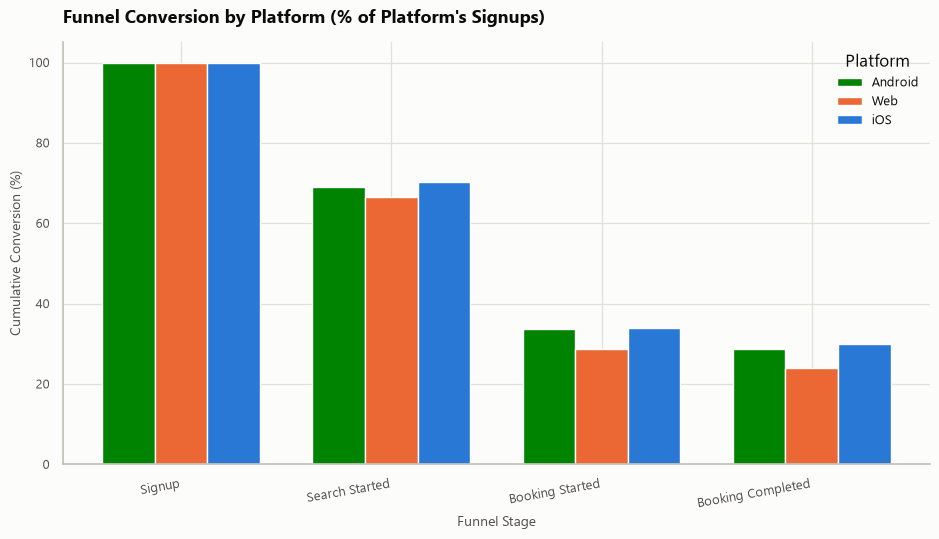

,Android,Web,iOS
stage,,,
Signup,100.0,100.0,100.0
Search Started,68.9,66.5,70.2
Booking Started,33.6,28.6,34.0
Booking Completed,28.8,24.0,30.0


In [6]:
platform_funnels = {}
for platform in sorted(users["platform"].unique()):
    subset_ids = set(users.loc[users["platform"] == platform, "user_id"])
    platform_funnels[platform] = compute_funnel(users, events, subset_user_ids=subset_ids)

platform_conversion = pd.DataFrame({
    platform: df.set_index("stage")["pct_of_signups"] for platform, df in platform_funnels.items()
}).loc[FUNNEL_STAGES]

PLATFORM_COLOR = {"iOS": PALETTE[0], "Android": PALETTE[1], "Web": PALETTE[5]}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(FUNNEL_STAGES))
width = 0.25
for i, platform in enumerate(platform_conversion.columns):
    ax.bar(x + (i - 1) * width, platform_conversion[platform], width=width, label=platform,
           color=PLATFORM_COLOR[platform])
ax.set_xticks(x)
ax.set_xticklabels(FUNNEL_STAGES, rotation=10, ha="right")
style_axis(ax, "Funnel Conversion by Platform (% of Platform's Signups)", "Funnel Stage", "Cumulative Conversion (%)")
ax.legend(title="Platform", frameon=False, fontsize=9)
plt.tight_layout()
save_fig(fig, "26_funnel_by_platform", IMAGES_DIR)
plt.show()

platform_conversion.round(1)

**Business Insight.** Web lags iOS and Android at every single funnel
stage, with the gap widening progressively toward Booking Completed —
confirming Web's weakness isn't concentrated in one step but compounds
across the entire journey. iOS leads marginally over Android throughout.

**Recommendation.** A Web-specific funnel audit (page load speed, mobile
web layout, payment method support) is justified — the underperformance is
consistent enough across every stage to point to a platform-wide UX issue
rather than one fixable screen.

## Section 4 — Funnel by Acquisition Channel

**Business Question.** Which channels bring in users with real booking
intent, versus users who browse but rarely commit?

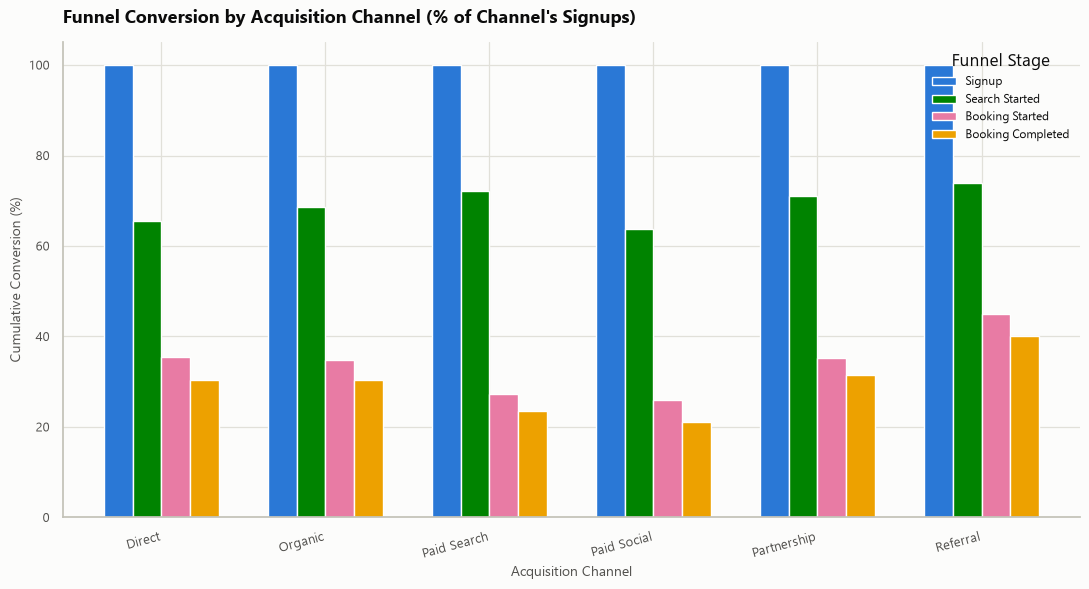

,Direct,Organic,Paid Search,Paid Social,Partnership,Referral
stage,,,,,,
Signup,100.0,100.0,100.0,100.0,100.0,100.0
Search Started,65.4,68.5,72.2,63.7,71.0,74.0
Booking Started,35.5,34.8,27.3,26.0,35.2,45.0
Booking Completed,30.4,30.4,23.5,21.0,31.4,40.0


In [7]:
channel_funnels = {}
for channel in sorted(users["acquisition_channel"].unique()):
    subset_ids = set(users.loc[users["acquisition_channel"] == channel, "user_id"])
    channel_funnels[channel] = compute_funnel(users, events, subset_user_ids=subset_ids)

channel_conversion = pd.DataFrame({
    channel: df.set_index("stage")["pct_of_signups"] for channel, df in channel_funnels.items()
}).loc[FUNNEL_STAGES]

fig, ax = plt.subplots(figsize=(11, 6))
channel_conversion.T.plot(kind="bar", ax=ax, color=PALETTE[:len(FUNNEL_STAGES)], width=0.7)
style_axis(ax, "Funnel Conversion by Acquisition Channel (% of Channel's Signups)", "Acquisition Channel", "Cumulative Conversion (%)")
ax.legend(title="Funnel Stage", frameon=False, fontsize=8.5)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
save_fig(fig, "27_funnel_by_channel", IMAGES_DIR)
plt.show()

channel_conversion.round(1)

**Business Insight.** Referral converts a substantially higher share of its
signups all the way to Booking Completed than any other channel, while
Paid Search shows a large gap between its search rate and its
booking-completion rate — i.e. **Paid Search drives a lot of browsing that
doesn't convert to booking intent**, the classic signature of lower-quality,
lower-intent paid traffic.

**Recommendation.** Reallocate a portion of Paid Search/Paid Social budget
toward scaling Referral, and separately review Paid Search keyword/audience
targeting — the channel is generating volume but not proportional booking
intent.

## Recommendations for Improving Conversion

1. **Fix the search-to-booking-intent step first** — it's the largest
   single leak in the funnel by a wide margin.
2. **Redesign the ride-option comparison screen** — the single most common
   point where non-converting sessions stop.
3. **Run a dedicated Web platform audit** — its underperformance compounds
   across every funnel stage, not just one.
4. **Shift acquisition spend toward Referral and away from Paid
   Search/Paid Social**, based on funnel-completion quality, not just
   signup volume.
5. Checkout/payment (Booking Started → Completed) is already comparatively
   strong — **deprioritise further investment there** relative to the
   steps above.